# ADCP Quality Flagging

Quality flagging of raw data. Only previous processing is removal of data before deployment and adding transducer's height.

Following the IOD Quality Flag Standard.

In [1]:
from mhkit import dolfyn
import xarray as xr
import my_functions as my
import numpy as np

In [2]:
# loading raw data
ds = dolfyn.load('A0524000_raw.nc')
ds

<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16672, dir: 4, range: 24, beam: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 133kB 2024-05-15T12:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float32 96B 3.52 4.52 5.52 ... 25.52 26.52
  * beam                 (beam) int32 16B 1 2 3 4
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 193 194 195 ... 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.507e+03 1.507e+03 ... 1.518e+03
    depth                (time) float32 67kB 22.36 22.36 22.26 ... 23.56 23.66
    pitch                (time) float32 67kB -6.44 -6.44 -6.45 ... -6.7 -6.68
    roll                 (time) float32 67kB -1.2 -1.22 -1.22 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.2 0.1845 ... nan nan
    amp                  (beam, range, time) uint8 2MB 141 142 143 ... 122 118
    corr                 (beam, range, time) uint8 2MB 123 124 123 ... 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 0 0 0 0 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 600kB 0.3584 ... -0.993
Attributes: (12/40)
    firmware_ver:              50.4
    inst_make:                 TRDI
    inst_type:                 ADCP
    rotate_vars:               ['vel']
    has_imu:                   0
    inst_model:                Workhorse
    ...                        ...
    power_level:               255
    serialnum:                 21788
    range_offset:              1.4
    fs:                        0.0011363636363636363
    declination:               -0.9
    declination_in_orientmat:  1

### Adding quality flags to datasets

Flagging arrays are created for corresponding dataset, then saved as ancillary variables.

Numeric flags with description of:
- Passing all tests
- Unkown
- Above surface
- Contaminated from surface interference
- Below correlation threshold 64
- Signal amplitude outlier
- Compass heading declination
- Pressure failure
- Missing data

In [3]:
# Creating flagging arrays for raw data, default values are (2,2) indicating unknown quality
qc1 = xr.full_like(ds['vel'], 2)        # primary quality flags
qc2 = xr.full_like(ds['vel'], 2)        # secondary quality flags

# Create masks 
# values above surface, True where range > depth
mask_above_surface = ds['range'] > ds['depth']   

# values contaminated from surface interference (upper 15%)
mask_surface_interference = (ds['range']/ds['depth'] >= 0.85) & (ds['range']/ds['depth'] <= 1)

# values below correlation threshold
corr_threshold = 64
mask_below_corr_thresh = (ds['corr'] <= corr_threshold).any(dim='beam')

# amplitude outliers
bottom_threshold = 225
surface_threshold = 100
mask_outlier = (~my.detect_outliers(ds, bottom_threshold, surface_threshold, set_to_NaN=False))

# NaN values
mask_NaN = np.isnan(ds['vel'])

# values affected by compass deviation
heading_thresh = 5
heading_start = ds['heading'].isel(time=0).values
# Calculate absolute angular difference 
heading_diff = ds['heading'] - heading_start
angular_diff = np.abs((heading_diff + 180) % 360 - 180)
# Mask where deviation from start exceeds threshold
mask_heading = angular_diff > heading_thresh

# Mask pressure failure
# First, detect constant values for pressure
pressure_diff_thresh = 0.001 # allow for rounded values of last digit
mask_pressure_constant = my.detect_const_pressure(ds, pressure_diff_thresh) # Detects three consecutive constant values

# Secondly, detect deviation of expected depth interval
depth_expected = 22           # from setup  
tidal_amplitude_expected = 3  # corresponds to tidal amplitude 6, higer than actual
mask_pressure_deviation = (
    (ds['pressure'] > depth_expected + tidal_amplitude_expected) |
    (ds['pressure'] < depth_expected - tidal_amplitude_expected)
)

# Finally, flag only velocities within tidal range according to pressure errors detected
pressure_errors = (mask_pressure_deviation | mask_pressure_constant)
ds_valid_vel = ds.where(~pressure_errors, drop=True) # base tidal range on valid values
HT_max = ds_valid_vel['depth'].max()
LT_min = ds_valid_vel['depth'].min()

mask_pressure_failure = (
    (ds['range'] >= LT_min) &
    (ds['range'] <= HT_max) &
    pressure_errors
)

# passed all checks
mask_passed = (
    ~mask_above_surface
    & ~mask_surface_interference
    & ~mask_below_corr_thresh
    & ~mask_outlier
    & ~mask_NaN
    & ~mask_heading
    & ~mask_pressure_failure
    )
    
masks = {
'above_surface': mask_above_surface,
'surface_interference': mask_surface_interference,
'below_corr_thresh': mask_below_corr_thresh,
'outlier': mask_outlier,
'compass_heading_deviation': mask_heading,
'pressure_failure': mask_pressure_failure,
'NaN': mask_NaN,
'passed': mask_passed
}

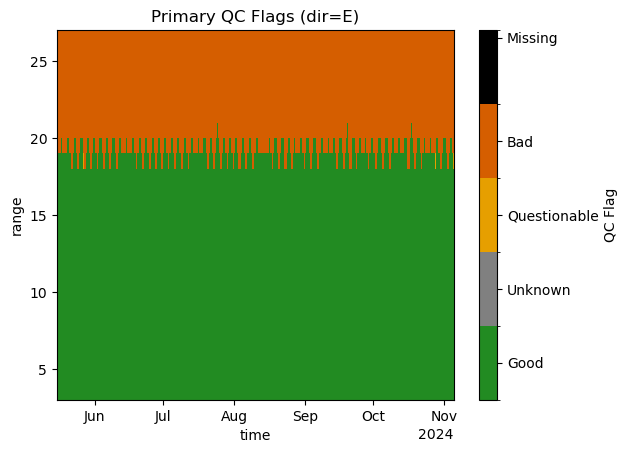

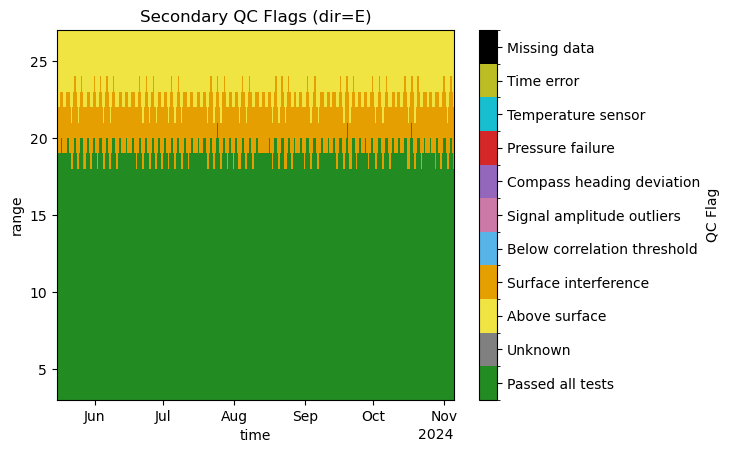

In [4]:
# Apply masks to corresponding values to flagging arrays
qc1, qc2 = my.apply_qc_mask(masks['below_corr_thresh'], (3, 5), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['outlier'], (3, 6), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['NaN'], (9, 7), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['passed'], (1, 1), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['surface_interference'], (4, 4), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['above_surface'], (4, 3), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['compass_heading_deviation'], (3, 7), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['pressure_failure'], (3, 8), qc1, qc2)


qc1 = qc1.transpose('dir', 'range', 'time')
qc2 = qc2.transpose('dir', 'range', 'time')

# Add the numeric QC flags
ds['vel_qc_primary'] = qc1.assign_attrs({
    'long_name': 'Quality flags for variable (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 
        '1=Good \n'
        '2=Unknown \n'
        '3=Questionable \n'
        '4=Bad \n'
        '9=Missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['vel_qc_secondary'] = qc2.assign_attrs({
        'long_name': 'Quality flag descriptions for variable (secondary level)',
        'flag_values': [1, 2, 3, 4, 5, 6, 7],  
        'flag_meanings':
            '1=Passed all tests \n'
            "2=Unkown \n"
            '3=Above_surface\n'
            '4=Contaminated_from_surface_interference\n'
            '5=Below_correlation_threshold_64\n'
            '6=Signal_amplitude_outliers\n'
            '7=Missing_data\n',
        'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
    })

# Link as ancillary variables
ds['vel'].attrs['ancillary_variables'] = 'vel_qc_primary vel_qc_secondary'

my.plot_qc_primary(ds, direction=0)

my.plot_qc_secondary(ds, direction=0)  

In [5]:
ds

<xarray.Dataset> Size: 26MB
Dimensions:              (time: 16672, dir: 4, range: 24, beam: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 133kB 2024-05-15T12:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float32 96B 3.52 4.52 5.52 ... 25.52 26.52
  * beam                 (beam) int32 16B 1 2 3 4
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/23)
    number               (time) uint32 67kB 193 194 195 ... 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.507e+03 1.507e+03 ... 1.518e+03
    depth                (time) float32 67kB 22.36 22.36 22.26 ... 23.56 23.66
    pitch                (time) float32 67kB -6.44 -6.44 -6.45 ... -6.7 -6.68
    roll                 (time) float32 67kB -1.2 -1.22 -1.22 ... -1.28 -1.28
    ...                   ...
    corr                 (beam, range, time) uint8 2MB 123 124 123 ... 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 0 0 0 0 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 600kB 0.3584 ... -0.993
    vel_qc_primary       (dir, range, time) float32 6MB 1.0 1.0 1.0 ... 4.0 4.0
    vel_qc_secondary     (dir, range, time) float32 6MB 1.0 1.0 1.0 ... 3.0 3.0
Attributes: (12/40)
    firmware_ver:              50.4
    inst_make:                 TRDI
    inst_type:                 ADCP
    rotate_vars:               ['vel']
    has_imu:                   0
    inst_model:                Workhorse
    ...                        ...
    power_level:               255
    serialnum:                 21788
    range_offset:              1.4
    fs:                        0.0011363636363636363
    declination:               -0.9
    declination_in_orientmat:  1

In [6]:
dolfyn.save(ds, 'A0524000_flagged.nc')    